# Data Analysis for READ-MAS Agents

This notebook contains all the data analysis and EDA performed on the experiment datasets. It consists of:
- a section to import libraries and define constants that include mapping dictionaries and lists for metrics, column renaming, and file mappings per RQ and EDA requirements.
- a section for reusable helper functions to load experiment datasets, prepare group data frames for ANOVA analysis, and perform the ANOVA and post hoc tests
- multiple sections for ANOVA analysis of the RQs
- EDA for benchmarking
- EDA for training and evaluation of the individual agents

## Import Libraries and Define Constants

In [219]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import  pingouin 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# The parent path to the benchmark experiment runs
EXPERIMENT_PATH = '../../benchmark_runs/'

# Column renames for LLM as a Judge benchmark runs
RENAME_BENCHMARK = {
  'runs/benchmark_runs/metrics.json:agent':                    'agent',
  'runs/benchmark_runs/metrics.json:model':                    'model',
  'runs/benchmark_runs/metrics.json:rag':                      'rag',
  'runs/benchmark_runs/metrics.json:DesignAccuracy [GEval]':   'design_accuracy',
  'DesignAccuracy [GEval]':                                    'design_accuracy',
  'runs/benchmark_runs/metrics.json:faithfulness (ragas)':     'ragas_faithfulness',
  'runs/benchmark_runs/metrics.json:RAGAS':                    'ragas',
}
# Columns to keep in the benchmark runs data frame
KEEP_BENCHMARK = ['agent', 'model', 'rag', 'design_accuracy', 'ragas_faithfulness', 'ragas']

# Column renames for code benchmark runs
RENAME_CODE_BENCHMARK = {
  'code.agent_name':                                          'agent',
  'code.model':                                               'model',
  'code.rag':                                                 'rag',
  'pass@1':                                                   'pass_at_1',
  'pass@1plus':                                               'pass_at_1plus',
  'code.dataset':                                             'benchmark',
  'runs/code_benchmark_runs/metrics.json:pass@1':             'pass_at_1',
  'runs/code_benchmark_runs/metrics.json:pass@1plus':         'pass_at_1plus',
}

# Columns to keep for code benchmark runs
KEEP_CODE_BENCHMARK = ['agent', 'model', 'rag', 'pass_at_1', 'pass_at_1plus', 'benchmark']

# Column renames for plain LLM code benchmark runs
RENAME_LLM_BENCHMARK = {
  'runs/llm_benchmark_runs/metrics.json:model':                     'model',
  'runs/llm_benchmark_runs/metrics.json:pass@1':                    'pass_at_1',
  'runs/llm_benchmark_runs/metrics.json:pass@1plus':                'pass_at_1plus',
  'runs/llm_benchmark_runs/metrics.json:benchmark':                 'benchmark',
}

# Columns to keep for plain LLM code benchmark runs
KEEP_LLM_BENCHMARK = ['agent', 'model', 'pass_at_1', 'pass_at_1plus', 'benchmark']

# LLM as a Judge and RAGAS metrics
BENCHMARK_METRICS = ['design_accuracy', 'ragas_faithfulness', 'ragas']

# HumanEval and MBPP metrics for code benchmarking
CODE_METRICS = ['pass_at_1', 'pass_at_1plus']

# Metrics without RAGAS for RQ5
NO_RAGAS_METRICS = ['design_accuracy']

# Constants for experiment groups corresponding to the Research Questions
# Mapping of custom benchmarks and metrics
BENCHMARK_COL_METRICS_MAP = {
  'benchmark': {
    'rename_cols': RENAME_BENCHMARK,
    'keep_cols': KEEP_BENCHMARK,
    'metrics': BENCHMARK_METRICS
  }
}

# Mapping of custom benchmarks and metrics for NO RAGAS use case
NO_RAGAS_BENCHMARK_COL_METRICS_MAP = {
  'benchmark': {
    'rename_cols': RENAME_BENCHMARK,
    'keep_cols': KEEP_BENCHMARK,
    'metrics': NO_RAGAS_METRICS
  }
}

# Mapping of coding benchmarks and metrics
CODE_BENCHMARK_COL_METRICS_MAP = {
  'humaneval': {
    'rename_cols': RENAME_CODE_BENCHMARK,
    'keep_cols': KEEP_CODE_BENCHMARK,
    'metrics': CODE_METRICS    
  },
  'mbpp': {
    'rename_cols': RENAME_CODE_BENCHMARK,
    'keep_cols': KEEP_CODE_BENCHMARK,
    'metrics': CODE_METRICS    
  }
}

# Code benchmark mappings with no RAG for LLM vs agent comparison (RQ4)
CODE_LLM_COL_METRICS_MAP = {
  'humaneval': {
    'rename_cols': RENAME_CODE_BENCHMARK | RENAME_LLM_BENCHMARK,
    'keep_cols': KEEP_LLM_BENCHMARK,
    'metrics': CODE_METRICS    
  },
  'mbpp': {
    'rename_cols': RENAME_CODE_BENCHMARK | RENAME_LLM_BENCHMARK,
    'keep_cols': KEEP_LLM_BENCHMARK,
    'metrics': CODE_METRICS    
  }
}

# RQ1: Gemini - Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ1_BENCHMARK_FILES_GEMINI = {
    'benchmark': ('single_agent_benchmark_gemini.csv', 'read_agent_benchmark_gemini.csv'),
    'humaneval': ('single_agent_code_benchmark_humaneval_gemini.csv',
                'read_agent_code_benchmark_humaneval_gemini.csv'),
    'mbpp':      ('single_agent_code_benchmark_mbpp_gemini.csv',
                'read_agent_code_benchmark_mbpp_gemini.csv'),
}

# RQ1: GPT-5-mini - Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ1_BENCHMARK_FILES_OPENAI = {
    'humaneval': ('single_agent_code_benchmark_humaneval_openai.csv',
                'read_agent_code_benchmark_humaneval_openai.csv'),
}

# Columns and metrics map combining custom and code benchmarks.
FULL_COL_METRICS_MAP = BENCHMARK_COL_METRICS_MAP | CODE_BENCHMARK_COL_METRICS_MAP

# No RAGAS columns and metrics map combining custom and code benchmarks.
NO_RAGAS_COL_METRICS_MAP = NO_RAGAS_BENCHMARK_COL_METRICS_MAP | CODE_BENCHMARK_COL_METRICS_MAP

# Numeric columns (used in EDA data frames)
NUMERIC_COLS = ['pass_at_1', 'pass_at_1plus', 'design_accuracy', 'ragas_faithfulness', 'ragas']

# RQ2: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ2_BENCHMARK_FILES = {
    'benchmark': ('read_agent_benchmark_claude.csv', 'read_agent_benchmark_gemini.csv', 'read_agent_benchmark_openai.csv'),
    'humaneval': ('read_agent_code_benchmark_humaneval_claude.csv',
                'read_agent_code_benchmark_humaneval_gemini.csv', 
                'read_agent_code_benchmark_humaneval_openai.csv'),
    'mbpp':      ('single_agent_code_benchmark_mbpp_gemini.csv',
                'read_agent_code_benchmark_mbpp_gemini.csv'),
}

# RQ4: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ4_BENCHMARK_FILES = {
    'humaneval': ('read_agent_code_benchmark_humaneval_claude.csv',
                'llm_code_benchmark_humaneval_claude.csv'),
    #'mbpp':      ('read_agent_code_benchmark_mbpp_claude.csv',
    #            'llm_code_benchmark_mbpp_claude.csv'),
}

# RQ5: Custom benchmark, HumanEval and MBPP code benchmark experiment datasets
RQ5_BENCHMARK_FILES = {
    'benchmark': ('read_agent_benchmark_gemini.csv', 'read_agent_benchmark_gemini_no_rag.csv'),
    #'humaneval': ('read_agent_code_benchmark_humaneval_gemini.csv',
    #            'read_agent_code_benchmark_humaneval_gemini_no_rag.csv'),
    #'mbpp':      ('read_agent_code_benchmark_mbpp_gemini.csv',
    #            'read_agent_code_benchmark_mbpp_gemini_no_rag.csv'),
}

# EDA file groups: all benchmark and code benchmark files for exploratory analysis
EDA_CODE_BENCHMARK_FILES = {
  'humaneval': (
    'read_agent_code_benchmark_humaneval_claude.csv',
    'read_agent_code_benchmark_humaneval_gemini.csv',
    'read_agent_code_benchmark_humaneval_openai.csv',
    'single_agent_code_benchmark_humaneval_gemini.csv',
    'single_agent_code_benchmark_humaneval_openai.csv',
  ),
  'mbpp': (
    'read_agent_code_benchmark_mbpp_gemini.csv',
    'single_agent_code_benchmark_mbpp_gemini.csv',
  ),
}

EDA_LLM_BENCHMARK_FILES = {
  'humaneval': ('llm_code_benchmark_humaneval_claude.csv',),
  'mbpp':      ('llm_code_benchmark_mbpp_claude.csv',),
}

EDA_DESIGN_BENCHMARK_FILES = {
  'benchmark': (
    'read_agent_benchmark_claude.csv',
    'read_agent_benchmark_gemini.csv',
    'read_agent_benchmark_gemini_no_rag.csv',
    'read_agent_benchmark_openai.csv',
    'single_agent_benchmark_gemini.csv',
  ),
}



## Helper Functions for Experiment Data Loading and Perform ANOVA

Helper functions

In [233]:
def load_experiment_dataset(filename: str, rename_cols: dict[str, str], keep_cols: list[str]) -> pd.DataFrame:
    """This function loads an experiment data in CSV format into a data frame, filters out the baselines, renames the columns, and keeps only the columns needed for the analysis.
    
    Args:
        filename: the relative path to the experiment dataset
        rename_cols: a dict to rename the dataset columns
        keep_cols: the columns to keep in the data frame
        
    Returns:
        A Pandas data frame
    """
    df = pd.read_csv(EXPERIMENT_PATH + filename)
    df = df[df['typ'].isin(['branch_base', 'branch_commit'])]
    df = df.rename(columns=rename_cols)
    
     # Set agent to llm for LLM benchmark datasets
    if 'agent' not in df.columns:
      df['agent'] = 'llm'

    return df[keep_cols]


In [234]:
def get_group_dfs(group_files: dict[str, tuple[str, ...]], group_col_metrics_map: dict[str, dict[str, str]]) -> list[dict]:
  """This function prepares a list of dictionaries containing sets of data frames and associated metrics that are necessary for a particular ANOVA test or EDA analysis.
  
  Args:
    group_files: a dictionary of experiment files grouped by benchmarks used for a specific test or EDA
    group_col_metrics_map: a map of field renamings and metrics for a required test or EDA
    
  Returns:
    a list of dictionaries containing group data frames and metrics grouped by benchmarks
  
  """
  group_dfs = []
  for benchmark, files in group_files.items():
    config = group_col_metrics_map[benchmark]
    rename_cols = config['rename_cols']
    keep_cols = config['keep_cols']
    metrics = config['metrics']
    
    df_list = [
        load_experiment_dataset(f, rename_cols, keep_cols) 
        for f in files
    ]
    
    group_df = pd.concat(df_list, ignore_index=True)
        
    group_dfs.append({'benchmark': benchmark, 'group_df': group_df, 'metrics': metrics})

  return group_dfs

In [235]:
def perform_anova(benchmark: str, group_df: pd.DataFrame, metrics: list[str], group: str):
    """This function performs ANOVA assumption checks, ANOVA, and post hoc tests 
    and displays results as Markdown tables for dissertation manuscript use.
    
    Args:
        benchmark: the benchmark for which the ANOVA is performed
        group_df: the combined data frame for a particular hypothesis test
        metrics: the list of metrics serving as a target for the ANOVA tests
        group: the categorical variable ANOVA compares
    """
    
    # Explicit coercion of metric values to numeric since LLM file stores pass values as strings, which causes errors in pingouin.
    group_df = group_df.copy()
    for metric in metrics:
        group_df[metric] = pd.to_numeric(group_df[metric], errors='coerce')
    
    print(f"\n# Benchmark: {benchmark}")
    
    for metric in metrics:
        print(f"\n## Metric: {metric}")
        
        # ANOVA Assumption checks
        norm = pingouin.normality(data=group_df, dv=metric, group=group, method='shapiro')
        print("\n#### Shapiro-Wilk Normality Test")
        print(f"*p > 0.05 indicates normality*")
        print(norm[['W', 'pval', 'normal']].to_markdown(index=False))
        
        eq_var = pingouin.homoscedasticity(data=group_df, dv=metric, group=group, method='levene')
        print("\n#### Levene Homoscedasticity Test")
        print(f"*p > 0.05 indicates equal variances*")
        print(eq_var[['W', 'pval', 'equal_var']].to_markdown(index=False))
        
        normal = norm['normal'].all()
        equal_var = eq_var['equal_var'].iloc[0]
        
        # ANOVA/Kruskal-Wallis tests based on assumption check results
        if not normal:
            kw = pingouin.kruskal(data=group_df, dv=metric, between=group)
            print(f"\n#### Kruskal-Wallis Test (Non-Parametric)")
            print(kw.to_markdown(index=False))
            
            # Convert series to dataframe for markdown formatting
            medians = group_df.groupby(group)[metric].median().reset_index()
            medians.columns = [group, 'Median']
            print(f"\n#### Group Medians")
            print(medians.to_markdown(index=False))
            
        elif not equal_var:
            aov = pingouin.welch_anova(data=group_df, dv=metric, between=group)
            print(f"\n#### Welch's ANOVA")
            print(aov.to_markdown(index=False))
            print(f"\n**Summary:** F({aov.iloc[0]['ddof1']:.0f}, {aov.iloc[0]['ddof2']:.2f}) = {aov.iloc[0]['F']:.4f}, p = {aov.iloc[0]['p_unc']:.4f}")
            
            gh = pingouin.pairwise_gameshowell(data=group_df, dv=metric, between=group)
            print(f"\n#### Games-Howell Post Hoc Test")
            print(gh.to_markdown(index=False))
            
        else:
            aov = pingouin.anova(data=group_df, dv=metric, between=group, detailed=True)
            print(f"\n#### One-way ANOVA")
            print(aov.to_markdown(index=False))
            print(f"\n**Summary:** F({aov.iloc[0]['DF']}, {aov.iloc[1]['DF']}) = {aov.iloc[0]['F']:.4f}, p = {aov.iloc[0]['p_unc']:.4f}")
            
            tukey = pingouin.pairwise_tukey(data=group_df, dv=metric, between=group)
            print(f"\n#### Tukey HSD Post Hoc Test")
            print(tukey.to_markdown(index=False))

## Load Experiment Datasets

Load the experiment datasets and filter the experiments.

In [236]:
# RQ1 grouped datasets - Gemini
rq1_group_gemini_dfs = get_group_dfs(RQ1_BENCHMARK_FILES_GEMINI, FULL_COL_METRICS_MAP)

for group in rq1_group_gemini_dfs:
  print(f"Benchmark {group['benchmark']}  Metrics {group['metrics']}\n")
  print(f"RQ1 combined group dataset (Gemini) for {group['benchmark']}: \n")
  print(group['group_df'].head())
  print("\n\n")

# RQ1 grouped datasets - OpenAI
rq1_group_openai_dfs = get_group_dfs(RQ1_BENCHMARK_FILES_OPENAI, FULL_COL_METRICS_MAP)

for group in rq1_group_openai_dfs:
  print(f"RQ1 combined group dataset (OpenAI) for {group['benchmark']}: \n")
  print(group['group_df'].head())
  print("\n\n")

# RQ2 grouped datasets
rq2_group_dfs = get_group_dfs(RQ2_BENCHMARK_FILES, FULL_COL_METRICS_MAP)

for group in rq2_group_dfs:
  print(f"RQ2 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].head())
  print("\n\n")
  
# RQ4 grouped datasets
rq4_group_dfs = get_group_dfs(RQ4_BENCHMARK_FILES, CODE_LLM_COL_METRICS_MAP)

for group in rq4_group_dfs:
  print(f"RQ4 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].head())
  print("\n\n")
  
# RQ5 grouped datasets
rq5_group_dfs = get_group_dfs(RQ5_BENCHMARK_FILES, NO_RAGAS_COL_METRICS_MAP)

for group in rq5_group_dfs:
  print(f"RQ5 combined group dataset for {group['benchmark']}: \n")
  print(group['group_df'].head())
  print("\n\n")

# EDA grouped datasets
eda_code_group_dfs   = get_group_dfs(EDA_CODE_BENCHMARK_FILES, CODE_BENCHMARK_COL_METRICS_MAP)
eda_llm_group_dfs    = get_group_dfs(EDA_LLM_BENCHMARK_FILES, CODE_LLM_COL_METRICS_MAP)
eda_design_group_dfs = get_group_dfs(EDA_DESIGN_BENCHMARK_FILES, BENCHMARK_COL_METRICS_MAP)

Benchmark benchmark  Metrics ['design_accuracy', 'ragas_faithfulness', 'ragas']

RQ1 combined group dataset (Gemini) for benchmark: 

          agent             model   rag  design_accuracy  ragas_faithfulness  \
0  single_agent  gemini-2.5-flash  True            0.797               0.910   
1  single_agent  gemini-2.5-flash  True            0.840               0.703   
2  single_agent  gemini-2.5-flash  True            0.882               0.846   
3  single_agent  gemini-2.5-flash  True            0.828               0.894   
4  single_agent  gemini-2.5-flash  True            0.829               0.816   

   ragas  
0  0.697  
1  0.652  
2  0.670  
3  0.675  
4  0.639  



Benchmark humaneval  Metrics ['pass_at_1', 'pass_at_1plus']

RQ1 combined group dataset (Gemini) for humaneval: 

          agent             model   rag  pass_at_1  pass_at_1plus  benchmark
0  single_agent  gemini-2.5-flash  True      0.918          0.866  humaneval
1  single_agent  gemini-2.5-flash  True      0.9

## RQ1: Compare Single and Multi Agents

Does using multiple agents compared to a single agent improve the performance of the generated code, as measured by the HumanEval and MBPP benchmarks, and the design, as measured by custom LLM-as-a-Judge and RAGAS faithfulness metrics?

In [227]:
# RQ1 ANOVA analysis for experiments that used Gemini-2.5-flash model
for group in rq1_group_gemini_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.918068 | 0.341123 | True     |
| 0.947691 | 0.64127  | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|      W |       pval | equal_var   |
|-------:|-----------:|:------------|
| 9.7183 | 0.00594821 | False       |

#### Welch's ANOVA
| Source   |   ddof1 |   ddof2 |       F |     p_unc |      np2 |
|:---------|--------:|--------:|--------:|----------:|---------:|
| agent    |       1 |  13.256 | 6.41633 | 0.0246842 | 0.262789 |

**Summary:** F(1, 13.26) = 6.4163, p = 0.0247

#### Games-Howell Post Hoc Test
| A          | B            |   mean_A |   mean_B |   diff |        se |       T |     df |      pval |   hedges |
|:-----------|:-------------|---------:|---------:|-------:|----------:|--------:|-------:|----------:|---------:|
| read_agent | single_agent |

In [228]:
# RQ1 ANOVA analysis for experiments that used OpenAI GPT-5-mini model
for group in rq1_group_openai_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: humaneval

## Metric: pass_at_1

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.955342 | 0.731735 | True     |
| 0.962399 | 0.812845 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|        W |     pval | equal_var   |
|---------:|---------:|:------------|
| 0.605254 | 0.446687 | True        |

#### One-way ANOVA
| Source   |        SS |   DF |        MS |       F |         p_unc |        np2 |
|:---------|----------:|-----:|----------:|--------:|--------------:|-----------:|
| agent    | 0.0455058 |    1 | 0.0455058 | 333.865 |   4.55598e-13 |   0.948844 |
| Within   | 0.0024534 |   18 | 0.0001363 | nan     | nan           | nan        |

**Summary:** F(1, 18) = 333.8650, p = 0.0000

#### Tukey HSD Post Hoc Test
| A          | B            |   mean_A |   mean_B |   diff |         se |      T |     p_tukey |   hedges |
|:-----------|:------------

## RQ2: Multi-agent performance among LLMs

Which LLM among Claude Sonnet 4, Gemini 2.5 Flash, GPT-5 mini, and gpt-oss:20b results in the best coding performance from the design generated by the new multi-agent framework in the HumanEval and MBPP benchmarks, and the best design, as measured by custom LLM-as-a-Judge and RAGAS faithfulness metrics?

In [173]:
for group in rq2_group_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'model')



# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.974542 | 0.929467 | True     |
| 0.947691 | 0.64127  | True     |
| 0.924307 | 0.394278 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|       W |      pval | equal_var   |
|--------:|----------:|:------------|
| 4.60499 | 0.0190208 | False       |

#### Welch's ANOVA
| Source   |   ddof1 |   ddof2 |       F |      p_unc |      np2 |
|:---------|--------:|--------:|--------:|-----------:|---------:|
| model    |       2 | 15.6912 | 7.84425 | 0.00435042 | 0.475008 |

**Summary:** F(2, 15.69) = 7.8443, p = 0.0044

#### Games-Howell Post Hoc Test
| A                           | B                 |   mean_A |   mean_B |   diff |         se |        T |      df |       pval |   hedges |
|:----------------------------|:------------------|---------:|---------:|-------

AssertionError: Data must have at least two columns.

## RQ4: Compare READ-MAS with LLM

How does the code generated from the design of the new multi-agent framework compare to the code generated by Claude Sonnet 4, as evaluated by the HumanEval and MBPP benchmarks?

In [174]:
for group in rq4_group_dfs:
  perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'agent')


# Benchmark: humaneval

## Metric: pass_at_1

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.912598 | 0.299321 | True     |
| 0.870884 | 0.102365 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|        W |     pval | equal_var   |
|---------:|---------:|:------------|
| 0.152381 | 0.700851 | True        |

#### One-way ANOVA
| Source   |        SS |   DF |        MS |       F |       p_unc |        np2 |
|:---------|----------:|-----:|----------:|--------:|------------:|-----------:|
| agent    | 0.0114242 |    1 | 0.0114242 | 140.174 |   6.266e-10 |   0.886201 |
| Within   | 0.001467  |   18 | 8.15e-05  | nan     | nan         | nan        |

**Summary:** F(1, 18) = 140.1742, p = 0.0000

#### Tukey HSD Post Hoc Test
| A   | B          |   mean_A |   mean_B |    diff |         se |        T |     p_tukey |   hedges |
|:----|:-----------|---------:|---------:

## RQ5: Compare READ-MAS with and without RAG

How does the new multi-agent framework compare to a RAG agent in producing more accurate designs, using its generated code, as measured in the HumanEval and MBPP benchmarks, and using its design, as measured by custom LLM-as-a-Judge metrics?

In [229]:
# Run ANOVA on cleaned data
for group in rq5_group_dfs_clean:
    perform_anova(group['benchmark'], group['group_df'], group['metrics'], 'rag')


# Benchmark: benchmark

## Metric: design_accuracy

#### Shapiro-Wilk Normality Test
*p > 0.05 indicates normality*
|        W |     pval | normal   |
|---------:|---------:|:---------|
| 0.943292 | 0.590188 | True     |
| 0.891808 | 0.177702 | True     |

#### Levene Homoscedasticity Test
*p > 0.05 indicates equal variances*
|        W |     pval | equal_var   |
|---------:|---------:|:------------|
| 0.438478 | 0.516247 | True        |

#### One-way ANOVA
| Source   |         SS |   DF |          MS |         F |      p_unc |        np2 |
|:---------|-----------:|-----:|------------:|----------:|-----------:|-----------:|
| rag      | 0.00059405 |    1 | 0.00059405  |   2.47813 |   0.132851 |   0.121014 |
| Within   | 0.0043149  |   18 | 0.000239717 | nan       | nan        | nan        |

**Summary:** F(1, 18) = 2.4781, p = 0.1329

#### Tukey HSD Post Hoc Test
| A     | B    |   mean_A |   mean_B |   diff |         se |       T |   p_tukey |   hedges |
|:------|:-----|---------:|--

## EDA of Benchmarking Datasets

Exploratory Data Analysis for the Custom LLM-as-a-Judge and Code Benchmarking Experiment Datasets.

### Benchmarking EDA Setup

In [237]:
# Create dataframes by benchmark type: code, LLM, benchmark, and strip model names to plot friendly names
def simplify_model_names(s: str) -> str:
    for prefix in ('anthropic/', 'google/', 'openai/', 'gemini/', 'oopenai/'):
        s = s.replace(prefix, '')
    return s

# First impute group data frames with outliers
#eda_design_group_dfs = impute_outliers(eda_design_group_dfs, 'rag')
df_code = pd.concat([g['group_df'] for g in eda_code_group_dfs],   ignore_index=True)
df_llm  = pd.concat([g['group_df'] for g in eda_llm_group_dfs],    ignore_index=True)
df_bm   = pd.concat([g['group_df'] for g in eda_design_group_dfs], ignore_index=True)

for df in (df_code, df_llm, df_bm):
    df['model'] = df['model'].apply(simplify_model_names)
df_llm['rag'] = False

# Ensure values of metric columns are numeric
for df in (df_code, df_llm, df_bm):
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

### Distribution of Code Benchmark Metrics

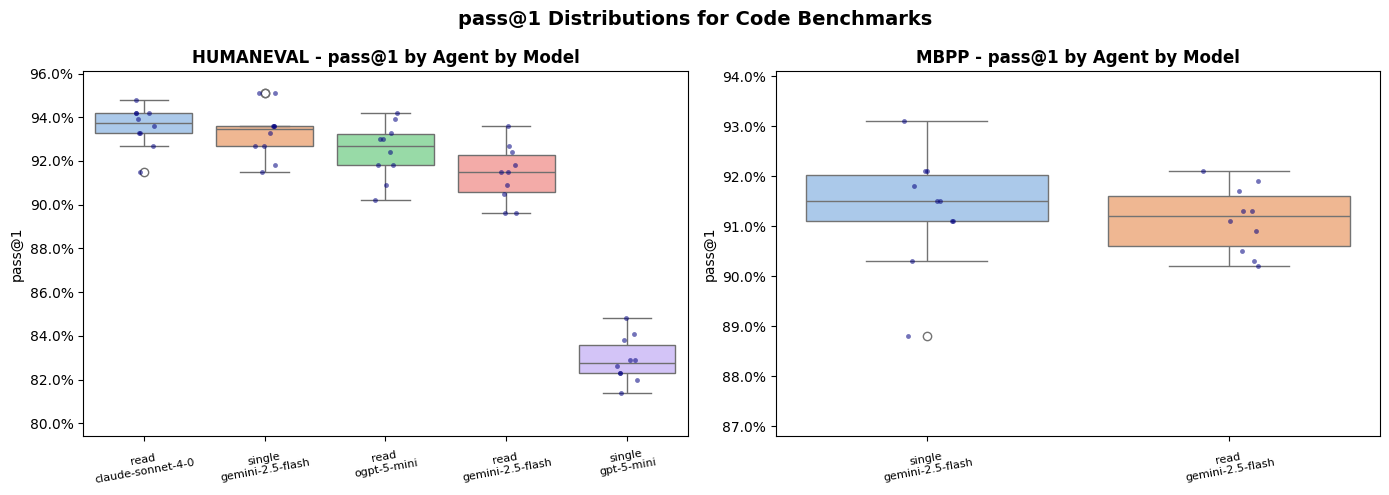

In [242]:
# Box and strip plots: pass@1 by model and dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, dataset in zip(axes, ['humaneval', 'mbpp']):
    sub = df_code[df_code['benchmark'] == dataset].copy()
    sub['agent_model'] = sub['agent'].str.replace('_agent', '') + '\n' + sub['model']
    order = sub.groupby('agent_model')['pass_at_1'].mean().sort_values(ascending=False).index

    sns.boxplot(data=sub, x='agent_model', y='pass_at_1', order=order,
                palette='pastel', linewidth=1, ax=ax)
    sns.stripplot(data=sub, x='agent_model', y='pass_at_1', order=order,
                color='navy', size=3.5, jitter=True, alpha=0.55, ax=ax)

    ax.set_title(f'{dataset.upper()} - pass@1 by Agent by Model', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('pass@1')
    ax.tick_params(axis='x', rotation=10, labelsize=8)
    ax.set_ylim(sub['pass_at_1'].min() - 0.02, sub['pass_at_1'].max() + 0.01)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle('pass@1 Distributions for Code Benchmarks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Distribution of Design Metrics (LLM-as-a-Judge and RAGAS)

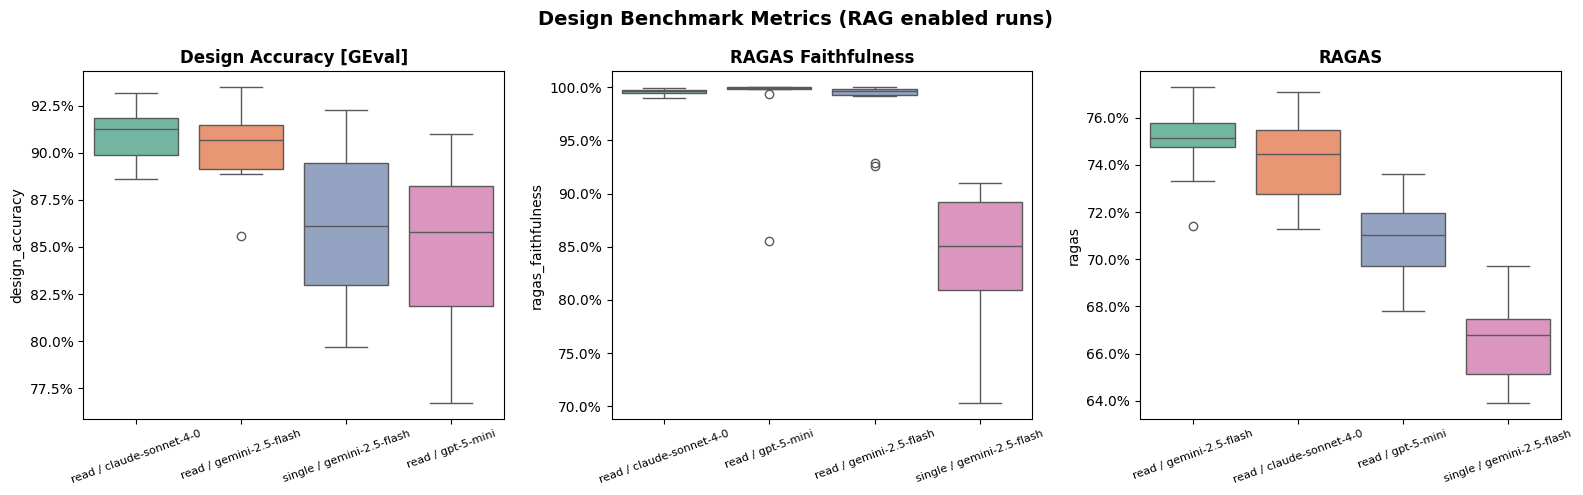

In [241]:
# Box plot of design_accuracy by agent and model
df_bm_rag = df_bm[df_bm['rag'] == True].copy()
df_bm_rag['agent_model'] = df_bm_rag['agent'].str.replace('_agent', '') + ' / ' + df_bm_rag['model']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('design_accuracy', 'Design Accuracy [GEval]'),
        ('ragas_faithfulness', 'RAGAS Faithfulness'),
        ('ragas', 'RAGAS')]

for ax, (metric, title) in zip(axes, metrics):
    order = (df_bm_rag.groupby('agent_model')[metric]
            .mean().sort_values(ascending=False).index)
    sns.boxplot(data=df_bm_rag, x='agent_model', y=metric, order=order,
                palette='Set2', linewidth=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle('Design Benchmark Metrics (RAG enabled runs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### READ-MAS Agents vs Plain LLM in Code Generation

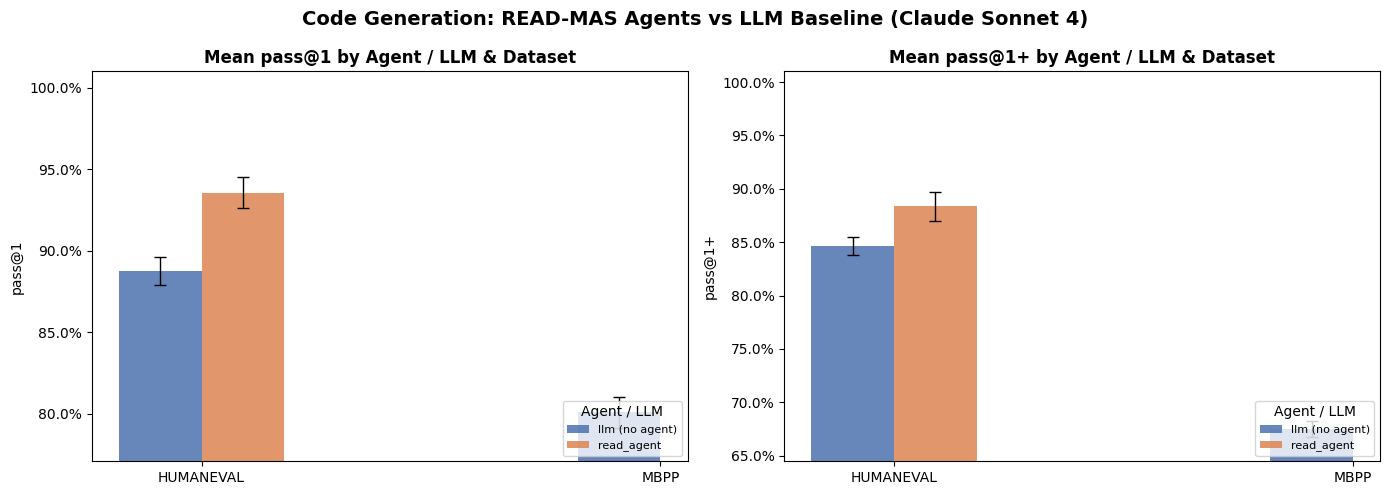

In [251]:
# Grouped bar chart of mean and std of metrics comparing code benchmarks for agent vs LLM use case (RQ4)
# First combine the agent and LLM datasets, selecting only the required model used (Claude) & columns
df_llm_plot = df_llm.copy()
df_llm_plot['agent'] = 'llm (no agent)'
df_code = df_code.copy()
df_code_claude = df_code[df_code['model'] == 'claude-sonnet-4-0']

df_code_llm = pd.concat([
    df_code_claude[['agent', 'model', 'benchmark', 'pass_at_1', 'pass_at_1plus']],
    df_llm_plot[['agent', 'model', 'benchmark', 'pass_at_1', 'pass_at_1plus']],
], ignore_index=True)

# Calculate aggregates for each agent/llm & benchmark category
agg = (df_code_llm
    .groupby(['agent', 'benchmark'])[['pass_at_1', 'pass_at_1plus']]
    .agg(['mean', 'std'])
    .reset_index())
agg.columns = ['agent', 'benchmark', 'p1_mean', 'p1_std', 'p1p_mean', 'p1p_std']

datasets = agg['benchmark'].unique()
agents   = agg['agent'].unique()
x        = np.arange(len(datasets))
width    = 0.18
offsets  = np.linspace(-(len(agents)-1)*width/2, (len(agents)-1)*width/2, len(agents))
colors   = sns.color_palette('deep', len(agents))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, metric, label in zip(axes, ['p1_mean', 'p1p_mean'], ['pass@1', 'pass@1+']):
    std_col = metric.replace('mean', 'std')
    for i, (agent, color) in enumerate(zip(agents, colors)):
        sub = agg[agg['agent'] == agent]
        vals = [sub[sub['benchmark'] == d][metric].values[0] if len(sub[sub['benchmark'] == d]) else np.nan for d in datasets]
        stds = [sub[sub['benchmark'] == d][std_col].values[0] if len(sub[sub['benchmark'] == d]) else 0 for d in datasets]
        ax.bar(x + offsets[i], vals, width, yerr=stds, label=agent,
            color=color, alpha=0.85, capsize=4, error_kw={'linewidth': 1})

    ax.set_xticks(x); ax.set_xticklabels([d.upper() for d in datasets])
    ax.set_title(f'Mean {label} by Agent / LLM & Dataset', fontweight='bold')
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    lo = agg[[metric]].min().min() - 0.03
    ax.set_ylim(max(0, lo), 1.01)
    ax.legend(title='Agent / LLM', fontsize=8, loc='lower right')

plt.suptitle('Code Generation: READ-MAS Agents vs LLM Baseline (Claude Sonnet 4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Effect of RAG on Design Accuracy

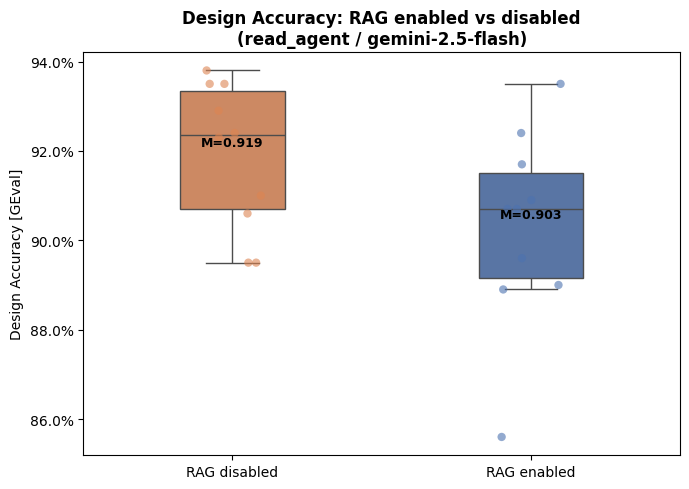

|   ('design_accuracy', 'count') |   ('design_accuracy', 'mean') |   ('design_accuracy', 'std') |   ('design_accuracy', 'min') |   ('design_accuracy', 'max') |
|-------------------------------:|------------------------------:|-----------------------------:|-----------------------------:|-----------------------------:|
|                             10 |                         0.919 |                        0.016 |                        0.895 |                        0.938 |
|                             10 |                         0.903 |                        0.022 |                        0.856 |                        0.935 |


In [160]:
# Box and strip plots for design_accuracy with vs without RAG
df_bm_gemini = df_bm[
    (df_bm['model'] == 'gemini-2.5-flash') &
    (df_bm['agent'] == 'read_agent')
].copy()
df_bm_gemini['RAG'] = df_bm_gemini['rag'].map({True: 'RAG enabled', False: 'RAG disabled'})

fig, ax = plt.subplots(figsize=(7, 5))
order_rag = ['RAG disabled', 'RAG enabled']
palette_rag = {'RAG enabled': '#4C72B0', 'RAG disabled': '#DD8452'}

sns.boxplot(data=df_bm_gemini, x='RAG', y='design_accuracy', order=order_rag,
            palette=palette_rag, width=0.35, fliersize=0, ax=ax)
sns.stripplot(data=df_bm_gemini, x='RAG', y='design_accuracy', order=order_rag,
            palette=palette_rag, size=6, jitter=True, alpha=0.6, ax=ax)

# Annotate means
for i, label in enumerate(order_rag):
    vals = df_bm_gemini[df_bm_gemini['RAG'] == label]['design_accuracy']
    ax.text(i, vals.mean() + 0.002, f'M={vals.mean():.3f}', ha='center',
            fontsize=9, color='black', fontweight='bold')

ax.set_title('Design Accuracy: RAG enabled vs disabled\n(read_agent / gemini-2.5-flash)',
            fontweight='bold')
ax.set_ylabel('Design Accuracy [GEval]')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Summary statistics in a table
print((df_bm_gemini.groupby('RAG')[['design_accuracy']]
    .agg(['count', 'mean', 'std', 'min', 'max']).round(3)).to_markdown(index=False))
